# Practical Assignment II: Multilayer Perceptrons

In this DataLab, you will revisit one of the MLP models you developed in the previous DataLab and dive deeper into the process of evaluating and improving an MLP model. 

**Learning objectives:**

At the end of this DataLab, you will be able to build MLPs using Keras for the following problem types:

- Plot and interpret learning curves
- Use early stopping in Keras
- Tune the learning rate
 
**Notebook contents:**
 
 1. Learning Curves
 2. Early Stopping in Keras
 3. Tuning Learning Rate

**Packages:**

Let's start by importing the basic packages required for this DataLab:

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**The dataset**

Today we will use the MNIST dataset provided by `keras`. This is the same dataset that you used in the previous DataLab for multi-class classification. If more information about the dataset is needed at any point, you can check the dataset documentation: https://keras.io/api/datasets/mnist/

Let's start by loading the dataset (notice that function ``mnist.load_data`` automatizally splits the data into a training set and a testing set):

In [8]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

To visualize how the samples look like, we can display a random sample from the dataset:

0


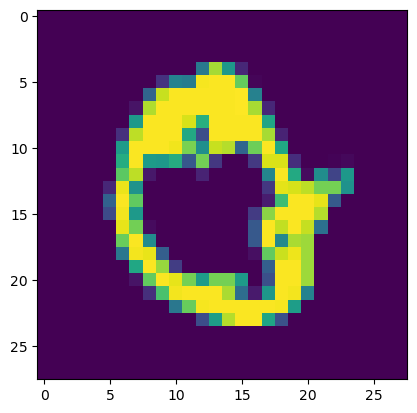

In [9]:
# random image
index = np.random.randint(0, 60000)
plt.imshow(X_train[index])
print(y_train[index])

We can also visualize the dimensions of the sets:

In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

## 1. Learning Curves

Learning curves are used to visually represent the learning process of a neural network over time. They plot the performance of the model on the training and validation datasets over the course of training iterations. Typically, the horizontal axis represents the number of epochs or iterations, and the vertical axis shows the loss or accuracy. By examining these curves, you can gain diagnose problems in the learning process, such as an underfit or overfit model, as well as whether the training and validation datasets are suitably representative.

**Task 1.1** Adjust the shapes of X_train, X_test, y_train, y_test to be compatible with the network below.

<img src="https://edirlei.com/images/nn2.png" width="500">

In [15]:
# YOUR CODE HERE #
from keras.utils import to_categorical
import numpy as np
# Reshape X_train and X_test to (, 784)
X_train = X_train.reshape((X_train.shape[0], -1))
X_test = X_test.reshape((X_test.shape[0], -1))

# One-hot encode y_train and y_test to (, 10)
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

**Task 1.2** Build the model. But this time, create a function for this task because you will have to repeat it a few times today.

In [12]:
from keras.models import Sequential
from keras.layers import Dense

def build_model(print_summary=False):
    model = Sequential()
    # YOUR CODE HERE #
    model.add(Dense(512, input_shape=(784,), activation='relu'))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    
    # display summary is optional
    if print_summary:
        model.summary()
    return model

model = build_model(print_summary=True)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 512)               401920    
                                                                 
 dense_5 (Dense)             (None, 256)               131328    
                                                                 
 dense_6 (Dense)             (None, 128)               32896     
                                                                 
 dense_7 (Dense)             (None, 10)                1290      
                                                                 
Total params: 567,434
Trainable params: 567,434
Non-trainable params: 0
_________________________________________________________________


**Task 1.3** Compile the model. Similarly to the previous task, create a function for the compilation process. 

In this DataLab we will use the Adam optimizer. During compilation, we can define an optimizer as `model.compile(optimizer='adam', ...)`

This is a good starting point, but it does not let us configure the optimizer. When we want to change the learning rate, we need to instantiate a new Adam optimizer and provide it to the compile function:

`from keras.optimizers import Adam`

`opt = Adam(learning_rate=0.001)`

`model.compile(optimizer=opt, ...)`

In this case, the parameter `learning_rate` of the `Adam` constructor defines the learning rate of the optimizer.

Note: If importing `Adam` gives an error, you are probably using a different version of Tensorflow. In this case, try importing `Adam` in the following way:

`from tensorflow.keras.optimizers import Adam`

In [21]:
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def compile_model(model, lr):
    # YOUR CODE HERE #
    opt = Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy']) 
    
    return model

model = compile_model(model, lr=0.001)
early_stopping = EarlyStopping(
    monitor='val_loss',    
    patience=3,            
    restore_best_weights=True
)


**Task 1.4** Train the model for 5 epochs. This time save the history `H = model.fit(...)`.

In [22]:
# YOUR CODE HERE #
H = model.fit(X_train, y_train, epochs=10, batch_size=64, callbacks=[early_stopping], validation_data=(X_test, y_test))

Epoch 1/10
938/938 [==============================] - 4s 4ms/step - loss: 0.0440 - accuracy: 0.9908 - val_loss: 0.1451 - val_accuracy: 0.9749
Epoch 2/10
938/938 [==============================] - 4s 4ms/step - loss: 0.0408 - accuracy: 0.9903 - val_loss: 0.1309 - val_accuracy: 0.9788
Epoch 3/10
938/938 [==============================] - 4s 4ms/step - loss: 0.0328 - accuracy: 0.9933 - val_loss: 0.1723 - val_accuracy: 0.9749
Epoch 4/10
938/938 [==============================] - 4s 4ms/step - loss: 0.0338 - accuracy: 0.9923 - val_loss: 0.1473 - val_accuracy: 0.9786
Epoch 5/10
938/938 [==============================] - 4s 5ms/step - loss: 0.0240 - accuracy: 0.9943 - val_loss: 0.1744 - val_accuracy: 0.9755


**Task 1.5** Evaluate the model using `model.evaluate()`.

In [24]:
val_loss, val_acc = model.evaluate(X_test, y_test)

print(val_loss, val_acc)

313/313 [==============================] - 0s 1ms/step - loss: 0.1309 - accuracy: 0.9788
0.1308874785900116 0.9787999987602234


**Task 1.6** Plot the learning curves for `loss` and `val_loss`. Write the code for plotting the curve in a function called `loss_plotter`. Example output:

<img src="https://edirlei.com/images/l_curve1.png" width="500">

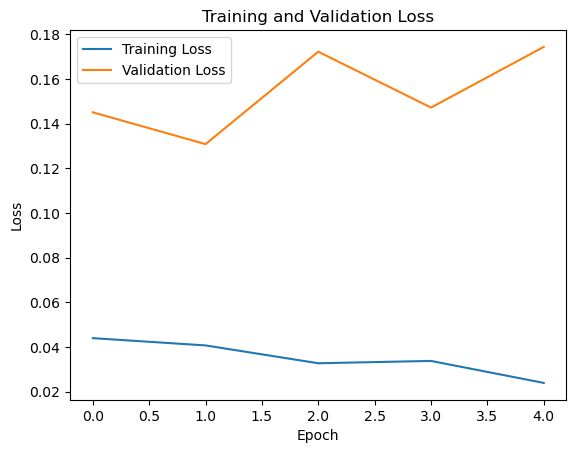

In [26]:
def loss_plotter(H):
    plt.plot(H.history['loss'], label='Training Loss')
    plt.plot(H.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

loss_plotter(H)

**Task 1.7** Plot the learning curves for `accuracy` and `val_accuracy`. Write the code for plotting the curve in a function called `accuracy_plotter`. Example output:

<img src="https://edirlei.com/images/l_curve2.png" width="500">

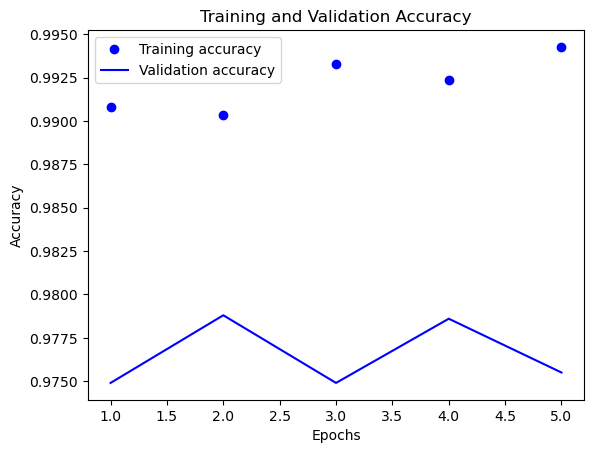

In [27]:
def accuracy_plotter(H):
    acc = H.history['accuracy']
    val_acc = H.history['val_accuracy']
    epochs = range(1, len(acc) + 1)
    
    plt.plot(epochs, acc, 'bo', label='Training accuracy')
    plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.show()
    
accuracy_plotter(H)

## 2. Early Stopping in Keras

Too many epochs can lead to overfitting of the training dataset, whereas too few may result in an underfit model. Early stopping is a regularization technique used in deep learning for preventing overfitting. This technique involves monitoring the model's performance on a validation dataset. During the training process, if the model's performance on the validation set begins to worsen or fails to improve for a predetermined number of epochs, the training process is halted. The idea is to stop training at the point where the model is generalized enough to perform well on both the training and validation datasets. Early stopping allows you to specify an arbitrary large number of training epochs and stop training once the model performance stops improving.

Let's start by creating a new model using the functions create in the previous tasks:

In [30]:
def build_model(print_summary=False):
    model = Sequential()
    # YOUR CODE HERE #
    model.add(Dense(512, input_shape=(784,), activation='relu'))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(10, activation='softmax'))
    
    
    # display summary is optional
    if print_summary:
        model.summary()
    return model

model = build_model(print_summary=True)

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_16 (Dense)            (None, 512)               401920    
                                                                 
 dense_17 (Dense)            (None, 256)               131328    
                                                                 
 dense_18 (Dense)            (None, 128)               32896     
                                                                 
 dense_19 (Dense)            (None, 10)                1290      
                                                                 


Total params: 567,434
Trainable params: 567,434
Non-trainable params: 0
_________________________________________________________________


**Task 2.1** Now, instead of setting a fixed number of epochs, use `EarlyStopping` callback. You can check the arguments for EarlyStopping callback in Keras documentation: https://keras.io/api/callbacks/early_stopping/
- Monitor the validation loss with a patience of 2. The patience is an argument of the `EarlyStopping` callback that defines the number of epochs with no improvement after which training will be stopped.
- Remember to restore the best weights. This is also defined by an argument of the `EarlyStopping` callback. Check Keras documentation to know how to use it.
- Notice that when using early stopping, you still need to set the number of epochs for training. Let's say you set the epochs to 10, and the model ran for 10 epochs. This means the stopping conditions you set in the callback did not occur therefore the training ran until the end. If the training runs for less than 10 epochs, this means early stopping kicked in.

In [31]:
from keras.callbacks import EarlyStopping
# YOUR CODE HERE #
early_stopping = EarlyStopping(
    monitor='val_loss',    
    patience=3,            
    restore_best_weights=True
)

In [33]:
def compile_model(model, lr):
    # YOUR CODE HERE #
    opt = Adam(learning_rate=0.001)
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy']) 
    
    return model

model = compile_model(model, lr=0.001)

**Task 2.2** Train the model with the callback you created in Task 2.1. From now on, always store the history `H = model.fit()`. Set the number of epochs such that you can observe the early stopping.

In [34]:
# YOUR CODE HERE #
H = model.fit(X_train, y_train, epochs=10, batch_size=64, callbacks=[early_stopping], validation_data=(X_test, y_test))

Epoch 1/10
938/938 [==============================] - 4s 4ms/step - loss: 1.2771 - accuracy: 0.8958 - val_loss: 0.2506 - val_accuracy: 0.9350
Epoch 2/10
938/938 [==============================] - 4s 4ms/step - loss: 0.1724 - accuracy: 0.9546 - val_loss: 0.1916 - val_accuracy: 0.9536
Epoch 3/10
938/938 [==============================] - 4s 4ms/step - loss: 0.1335 - accuracy: 0.9632 - val_loss: 0.1905 - val_accuracy: 0.9494
Epoch 4/10
938/938 [==============================] - 4s 4ms/step - loss: 0.1166 - accuracy: 0.9673 - val_loss: 0.1311 - val_accuracy: 0.9657
Epoch 5/10
938/938 [==============================] - 4s 4ms/step - loss: 0.0972 - accuracy: 0.9719 - val_loss: 0.1355 - val_accuracy: 0.9631
Epoch 6/10
938/938 [==============================] - 4s 5ms/step - loss: 0.0920 - accuracy: 0.9738 - val_loss: 0.1807 - val_accuracy: 0.9542
Epoch 7/10
938/938 [==============================] - 4s 5ms/step - loss: 0.0788 - accuracy: 0.9772 - val_loss: 0.1397 - val_accuracy: 0.9686


**Task 2.3** Plot the learning curves and interpret your results.

- Compare these to the learning curves from Task 1
- Did the model train for more than 5 epochs?
- Did the performance improve?
- Do you think the model is overfitting?

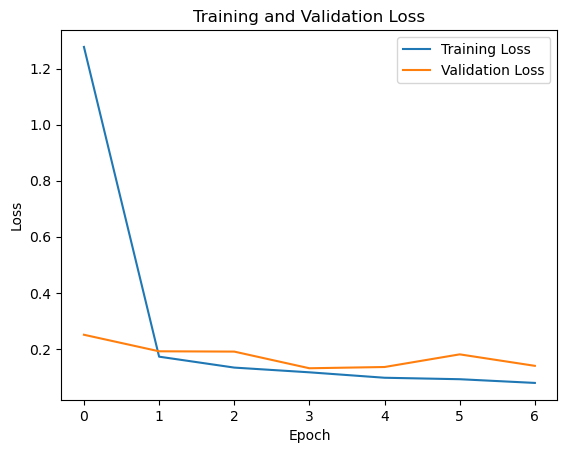

In [35]:
loss_plotter(H)

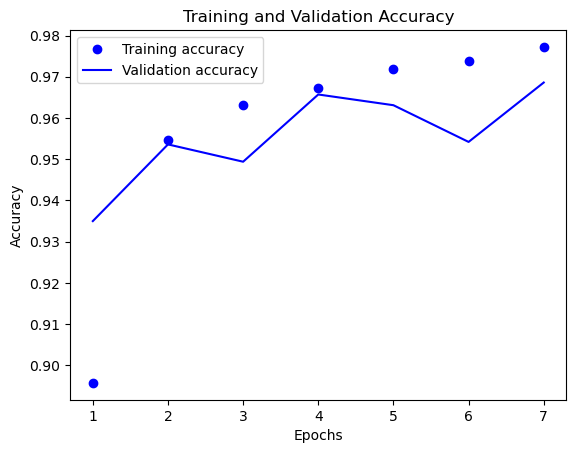

In [36]:
accuracy_plotter(H)

Write the results of your interpretation here.

## 3. Tuning Learning Rate

The learning rate in neural networks is a crucial hyperparameter that determines the size of the steps taken during the optimization process. It controls how much the weights of the network are adjusted with respect to the gradient of the loss function. A higher learning rate means the model makes larger updates to its weights and learns faster, but it can overshoot the optimal values, leading to unstable training or divergence. Conversely, a lower learning rate ensures more precise adjustments, but it can lead to slower convergence and may get stuck in local minima. Choosing the right learning rate is essential for efficient training; it's often a balancing act between speed of convergence and the risk of overshooting.

For the next tasks, you will use 5 different learning rates:

In [37]:
learning_rates = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

**Task 3.1** Train the model with the 5 learning rates. 
- Use the early stopping callback you created in the previous tasks. 
- When you are training the models, save each history object. 
- Set the number of epochs to a large enough number such that early stopping occurs in some of the learning rates.

In [44]:
from tensorflow.keras.optimizers import Adam

histories = []  # for plotting val_loss vs epochs for each learning rate
best_val_losses = []  # for plotting best_val_loss vs learning rate
learning_rates = [0.1, 0.01, 0.001, 0.0001, 0.00001]
early_stopping = EarlyStopping(
    monitor='val_loss',  
    patience=2,          
    restore_best_weights=True  
)

for lr in learning_rates:
    print('Training with:', lr)
    model = build_model()
    opt = Adam(learning_rate=0.001)
    
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    
    # Include the early_stopping callback created in Task 2.1
    history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), callbacks=[early_stopping])
    
    # Store the best validation loss from the history object
    best_loss = min(history.history['val_loss'])
    
    best_val_losses.append(best_loss)
    histories.append(history)


Training with: 0.1
Epoch 1/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.8956 - accuracy: 0.8996 - val_loss: 0.1971 - val_accuracy: 0.9450
Epoch 2/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1850 - accuracy: 0.9484 - val_loss: 0.1946 - val_accuracy: 0.9511
Epoch 3/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.1507 - accuracy: 0.9566 - val_loss: 0.1318 - val_accuracy: 0.9643
Epoch 4/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1249 - accuracy: 0.9644 - val_loss: 0.1365 - val_accuracy: 0.9647
Epoch 5/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.1080 - accuracy: 0.9707 - val_loss: 0.1198 - val_accuracy: 0.9680
Epoch 6/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.1029 - accuracy: 0.9724 - val_loss: 0.1485 - val_accuracy: 0.9625
Epoch 7/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0829 - accuracy: 0.9773 - val_loss: 0.1



**Task 3.1** Plot `val_loss` vs epochs for each learning rate.

Example output:

<img src="https://edirlei.com/images/l_curve3.png" width="500">

closer look:

<img src="https://edirlei.com/images/l_curve4.png" width="500">


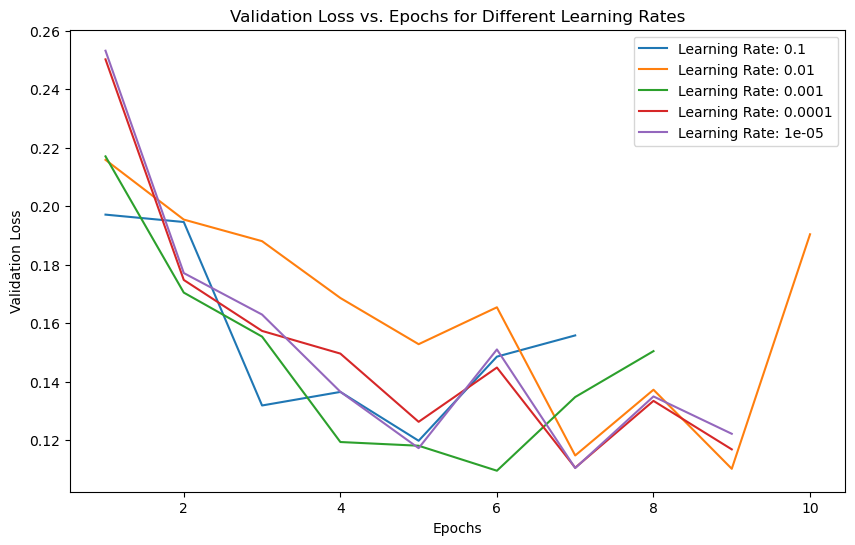

In [45]:
# Plot validation loss vs. epochs for each learning rate #
# YOUR CODE HERE #
def plot_val_loss(learning_rates, histories):
    plt.figure(figsize=(10, 6))
    for lr, history in zip(learning_rates, histories):
        val_loss = history.history['val_loss']
        epochs = range(1, len(val_loss) + 1)
        plt.plot(epochs, val_loss, label=f'Learning Rate: {lr}')
    
    plt.title('Validation Loss vs. Epochs for Different Learning Rates')
    plt.xlabel('Epochs')
    plt.ylabel('Validation Loss')
    plt.legend()
    plt.show()

# Assume 'histories' is a list of History objects from Keras, one for each learning rate
# and 'learning_rates' is a list of the learning rates used, in the same order.
plot_val_loss(learning_rates, histories)

These plots show which learning rate(s) are a good choice. But we can plot the best loss vs learning rate to see the relationship even better. 

**Task 3.2** Plot best validation loss vs learning rate.

Example output:

<img src="https://edirlei.com/images/l_curve5.png" width="500">

Notice that we can use the validation loss obtained at the end of training (last epoch). But that is not necessarily the best. In fact, we are using early stopping for this reason: when the model is not improving, stop with a patience. If you configured the callback correctly, it returns the best model. 
- You can use `model.evaluate()` to calculate the best validation loss.
- Alternatively, since patience is 2, the 3<sup>rd</sup> validation loss from the last must be the best loss in the history.

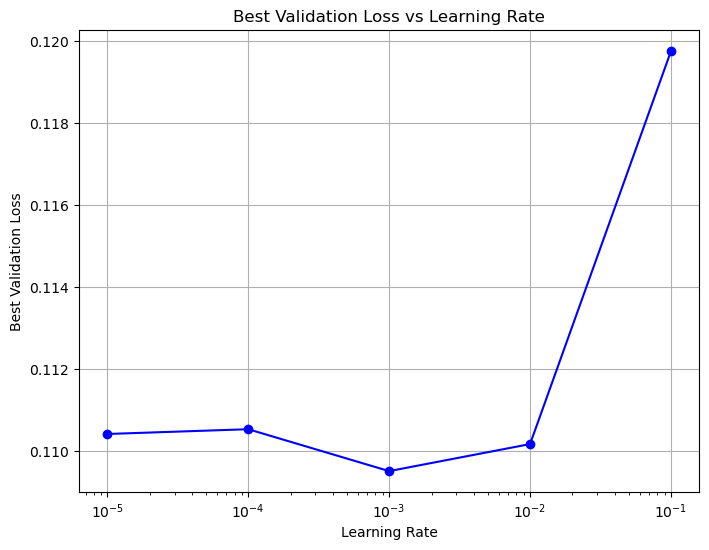

In [46]:
# Plot best validation loss vs learning rate # 
# YOUR CODE HERE #
plt.figure(figsize=(8, 6))
plt.plot(learning_rates, best_val_losses, marker='o', linestyle='-', color='b')
plt.xscale('log')  # Since learning rates vary in orders of magnitude, a log scale might be more appropriate
plt.xlabel('Learning Rate')
plt.ylabel('Best Validation Loss')
plt.title('Best Validation Loss vs Learning Rate')
plt.grid(True)
plt.show()